# Lexicon-based vs. Transformer-based Sentiment Analysis

VADER and TextBlob (lexicon-based) against DistilBERT fine-tuned on SST-2 (transformer), tested on SST-2 movie review sentences and on tweets (TweetEval).

## Research questions and hypotheses

**RQ1.** How does a transformer-based classifier (DistilBERT) compare with lexicon-based methods (VADER, TextBlob) on SST-2?
**H1.** DistilBERT performs better than both lexicon methods, especially on sentences where the sentiment depends on context (negation, contrast) rather than on single sentiment words.

**RQ2.** Does this still hold on text from a different domain? DistilBERT was fine-tuned on SST-2, so SST-2 is its home ground. Tweets are new to DistilBERT, while VADER was built for social media text.
**H2.** DistilBERT is still better on tweets, but the gap to the lexicon methods is smaller than on SST-2.

**RQ3.** What kinds of sentences does each model get wrong?

In [1]:
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"  # windows cache warning, harmless
import time
import pandas as pd
import matplotlib.pyplot as plt
import torch
from importlib.metadata import version
from datasets import load_dataset
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from transformers import pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from statsmodels.stats.contingency_tables import mcnemar

os.makedirs("results", exist_ok=True)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 100)
plt.rcParams["font.size"] = 13
plt.rcParams["pdf.fonttype"] = 42  # keeps text as real text in the pdf figures

print("torch", torch.__version__, "| cuda:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
for pkg in ["transformers", "datasets", "vaderSentiment", "textblob", "scikit-learn", "statsmodels", "pandas"]:
    print(pkg, version(pkg))

torch 2.5.1+cu121 | cuda: True
NVIDIA GeForce GTX 1660 Ti with Max-Q Design
transformers 5.16.1
datasets 5.0.1
vaderSentiment 3.3.2
textblob 0.20.1
scikit-learn 1.5.1
statsmodels 0.14.2
pandas 2.2.2


## 1. Data

In [2]:
sst2 = load_dataset("stanfordnlp/sst2")
print(sst2)

# test split has no labels (-1), so we use validation
df = sst2["validation"].to_pandas()
print(len(df), "sentences")
print(df["label"].value_counts())  # 1 = positive, 0 = negative

DatasetDict({
    train: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 872
    })
    test: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 1821
    })
})
872 sentences
label
1    444
0    428
Name: count, dtype: int64


In [3]:
df.sample(8, random_state=1)

,idx,sentence,label
523,523,a romantic comedy enriched by a sharp eye for manners and mores .,1
731,731,but what are adults doing in the theater at all ?,0
180,180,"unfortunately , it 's not silly fun unless you enjoy really bad movies .",0
185,185,"a must-see for the david mamet enthusiast and for anyone who appreciates intelligent , stylish moviemaking .",1
435,435,a marvel like none you 've seen .,1
34,34,"it does n't believe in itself , it has no sense of humor ... it 's just plain bored .",0
73,73,"one of creepiest , scariest movies to come along in a long , long time , easily rivaling blair witch or the others .",1
59,59,"it 's just disappointingly superficial -- a movie that has all the elements necessary to be a fascinating , involving character study , but never does more than scratch the surface .",0


The SST-2 sentences are already lowercased and tokenized (e.g. "it 's", "does n't"). All three models get exactly this text, nothing is cleaned.

In [4]:
tweets = load_dataset("cardiffnlp/tweet_eval", "sentiment")
print(tweets)

# labels here: 0 = negative, 1 = neutral, 2 = positive
# neutral tweets are dropped so it is the same positive/negative task as SST-2
tw = tweets["test"].to_pandas()
tw = tw[tw["label"] != 1].reset_index(drop=True)
tw["label"] = (tw["label"] == 2).astype(int)
tw = tw.rename(columns={"text": "sentence"})
print(len(tw), "tweets")
print(tw["label"].value_counts())

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
6347 tweets
label
0    3972
1    2375
Name: count, dtype: int64


In [5]:
tw.sample(8, random_state=1)

,sentence,label
3710,"""Drain the swamp.""Translation: Appoint the slimy creatures to my cabinet.#TrumpSpeak #TrumpTransitionTeam #NotMyPresident #DrainTheSwamp",0
4767,"@user young..rich..tall..handsome..kindest..cutest n walking ball of happiness ..... That's Chanyeol,undisputed king of fan service ❤",1
3588,YTP-Bee Movie: Barry Beetrays the Nazi Party via @user,0
5129,"Op-Ed: Obamacare isn't about health care, it's about power via @user",0
5522,Birds defeat Tipp in their home opener 38-28. #1-0 🏀,1
5351,"@user Yes and Marine Le Pen is both a fascist and a woman. You need to give people something to vote for, not just against.",0
4230,@user @user DEMS ARE THE PARTY OF HATE DIVISION UNEMPLOYMENT CORRUPTION WELFARE DUMB DOWN EDUCATION NEED TO SAY MORE ?,0
2349,What I'm thankful for this @user season! #TakeNote #HappyThanksgiving,1


The tweets are raw text. In TweetEval, user names are already replaced by "@user"; hashtags and emojis are kept. There are more negative than positive tweets (3972 vs 2375).

## 2. Running the three models

In [6]:
vader = SentimentIntensityAnalyzer()

model_name = "distilbert/distilbert-base-uncased-finetuned-sst-2-english"  # = distilbert-base-uncased-finetuned-sst-2-english
device = 0 if torch.cuda.is_available() else -1
clf = pipeline("sentiment-analysis", model=model_name, device=device)


def run_models(data, name):
    texts = data["sentence"].tolist()

    start = time.time()
    data["vader_score"] = [vader.polarity_scores(t)["compound"] for t in texts]
    print(name, "| VADER: %.2f s" % (time.time() - start))

    start = time.time()
    data["textblob_score"] = [TextBlob(t).sentiment.polarity for t in texts]
    print(name, "| TextBlob: %.2f s" % (time.time() - start))

    start = time.time()
    outputs = clf(texts, batch_size=32, truncation=True)
    print(name, "| DistilBERT: %.2f s" % (time.time() - start))
    data["distilbert_label"] = [o["label"] for o in outputs]
    data["distilbert_conf"] = [o["score"] for o in outputs]

    # only two classes, so score >= 0 -> positive, < 0 -> negative
    data["vader_pred"] = (data["vader_score"] >= 0).astype(int)
    data["textblob_pred"] = (data["textblob_score"] >= 0).astype(int)
    data["distilbert_pred"] = (data["distilbert_label"] == "POSITIVE").astype(int)

    for m in ["vader", "textblob", "distilbert"]:
        data[m + "_correct"] = data[m + "_pred"] == data["label"]

    print(name, "| VADER score exactly 0:", (data["vader_score"] == 0).sum(),
          "| TextBlob score exactly 0:", (data["textblob_score"] == 0).sum())
    return data


df = run_models(df, "SST-2")
tw = run_models(tw, "Tweets")

df.to_csv("results/predictions_sst2.csv", index=False)
tw.to_csv("results/predictions_tweets.csv", index=False)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

SST-2 | VADER: 0.09 s
SST-2 | TextBlob: 0.26 s
SST-2 | DistilBERT: 2.28 s
SST-2 | VADER score exactly 0: 141 | TextBlob score exactly 0: 129
Tweets | VADER: 0.57 s
Tweets | TextBlob: 1.53 s
Tweets | DistilBERT: 13.52 s
Tweets | VADER score exactly 0: 1183 | TextBlob score exactly 0: 2306


## 3. Evaluation

Precision, recall and F1 are for the positive class. Macro-F1 is the mean of the F1 scores of both classes. It matters mostly for the tweets, where there are more negative than positive examples.

In [7]:
models = {"VADER": "vader_pred", "TextBlob": "textblob_pred", "DistilBERT": "distilbert_pred"}
data_sets = {"SST-2": df, "Tweets": tw}

rows = []
for dname, data in data_sets.items():
    for mname, col in models.items():
        y_true = data["label"]
        y_pred = data[col]
        rows.append([dname, mname,
                     accuracy_score(y_true, y_pred),
                     precision_score(y_true, y_pred),
                     recall_score(y_true, y_pred),
                     f1_score(y_true, y_pred),
                     f1_score(y_true, y_pred, average="macro")])

metrics = pd.DataFrame(rows, columns=["Dataset", "Model", "Accuracy", "Precision", "Recall", "F1", "Macro-F1"])
metrics.round(3).to_csv("results/metrics.csv", index=False)
metrics.round(3)

,Dataset,Model,Accuracy,Precision,Recall,F1,Macro-F1
0,SST-2,VADER,0.631,0.595,0.860,0.703,0.607
1,SST-2,TextBlob,0.628,0.594,0.856,0.701,0.605
2,SST-2,DistilBERT,0.911,0.898,0.930,0.914,0.910
3,Tweets,VADER,0.704,0.563,0.933,0.703,0.704
4,Tweets,TextBlob,0.560,0.457,0.936,0.614,0.551
5,Tweets,DistilBERT,0.813,0.793,0.676,0.730,0.794


In [8]:
# H2: how much better is DistilBERT than each lexicon model, per dataset
for dname in data_sets:
    m = metrics[metrics["Dataset"] == dname].set_index("Model")
    for lex in ["VADER", "TextBlob"]:
        print("%-7s DistilBERT - %-8s  accuracy: %+.3f   macro-F1: %+.3f" % (
            dname, lex,
            m.loc["DistilBERT", "Accuracy"] - m.loc[lex, "Accuracy"],
            m.loc["DistilBERT", "Macro-F1"] - m.loc[lex, "Macro-F1"]))

SST-2   DistilBERT - VADER     accuracy: +0.280   macro-F1: +0.303
SST-2   DistilBERT - TextBlob  accuracy: +0.282   macro-F1: +0.305
Tweets  DistilBERT - VADER     accuracy: +0.109   macro-F1: +0.089
Tweets  DistilBERT - TextBlob  accuracy: +0.253   macro-F1: +0.242


In [9]:
for dname, data in data_sets.items():
    for mname, col in models.items():
        print("=====", dname, "-", mname)
        print(classification_report(data["label"], data[col], target_names=["negative", "positive"], digits=3))

===== SST-2 - VADER
              precision    recall  f1-score   support

    negative      0.730     0.393     0.511       428
    positive      0.595     0.860     0.703       444

    accuracy                          0.631       872
   macro avg      0.663     0.626     0.607       872
weighted avg      0.661     0.631     0.609       872

===== SST-2 - TextBlob
              precision    recall  f1-score   support

    negative      0.724     0.393     0.509       428
    positive      0.594     0.856     0.701       444

    accuracy                          0.628       872
   macro avg      0.659     0.624     0.605       872
weighted avg      0.658     0.628     0.607       872

===== SST-2 - DistilBERT
              precision    recall  f1-score   support

    negative      0.925     0.890     0.907       428
    positive      0.898     0.930     0.914       444

    accuracy                          0.911       872
   macro avg      0.911     0.910     0.910       872
weight

In [10]:
# check: does it matter where the 0 scores go? (0 -> negative instead of positive)
for dname, data in data_sets.items():
    for name, col in [("VADER", "vader_score"), ("TextBlob", "textblob_score")]:
        pred_a = (data[col] >= 0).astype(int)
        pred_b = (data[col] > 0).astype(int)
        print("%-7s %-9s  0 -> positive: acc %.3f, macro-F1 %.3f   |   0 -> negative: acc %.3f, macro-F1 %.3f" % (
            dname, name,
            accuracy_score(data["label"], pred_a), f1_score(data["label"], pred_a, average="macro"),
            accuracy_score(data["label"], pred_b), f1_score(data["label"], pred_b, average="macro")))

SST-2   VADER      0 -> positive: acc 0.631, macro-F1 0.607   |   0 -> negative: acc 0.666, macro-F1 0.664
SST-2   TextBlob   0 -> positive: acc 0.628, macro-F1 0.605   |   0 -> negative: acc 0.662, macro-F1 0.659
Tweets  VADER      0 -> positive: acc 0.704, macro-F1 0.704   |   0 -> negative: acc 0.727, macro-F1 0.717
Tweets  TextBlob   0 -> positive: acc 0.560, macro-F1 0.551   |   0 -> negative: acc 0.684, macro-F1 0.668


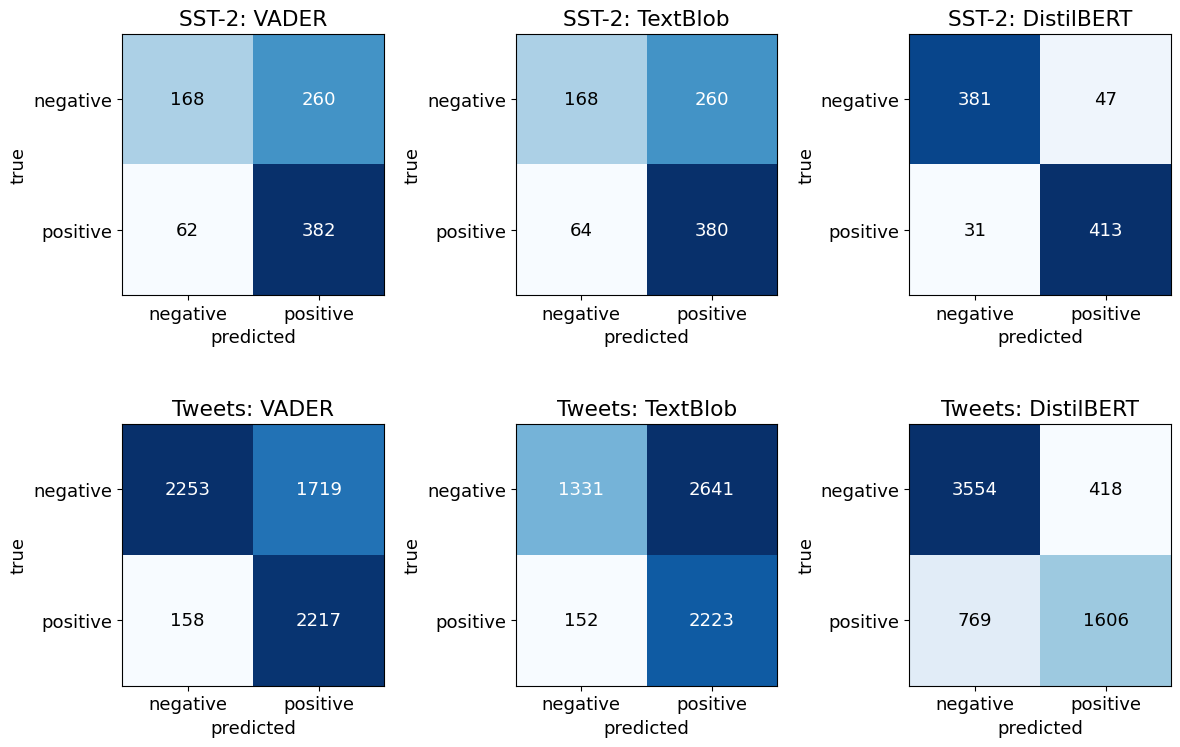

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for r, (dname, data) in enumerate(data_sets.items()):
    for c, (mname, col) in enumerate(models.items()):
        ax = axes[r, c]
        cm = confusion_matrix(data["label"], data[col])
        ax.imshow(cm, cmap="Blues")
        for i in range(2):
            for j in range(2):
                color = "white" if cm[i, j] > cm.max() / 2 else "black"
                ax.text(j, i, cm[i, j], ha="center", va="center", color=color)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["negative", "positive"])
        ax.set_yticks([0, 1])
        ax.set_yticklabels(["negative", "positive"])
        ax.set_xlabel("predicted")
        ax.set_ylabel("true")
        ax.set_title(dname + ": " + mname)
plt.tight_layout()
plt.savefig("results/confusion_matrices.png", dpi=300)
plt.savefig("results/confusion_matrices.pdf")
plt.show()

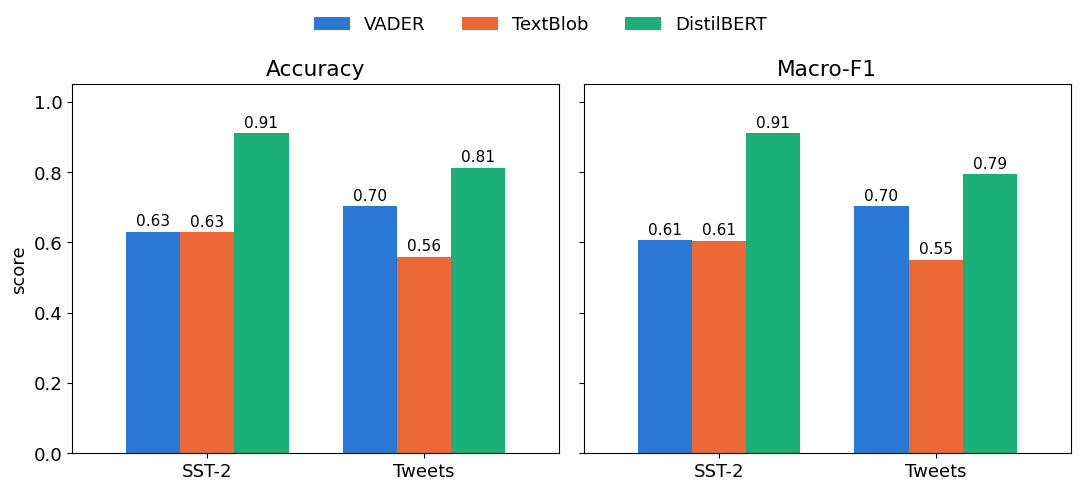

In [12]:
colors = ["#2a78d6", "#eb6834", "#1baf7a"]
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
for ax, metric in zip(axes, ["Accuracy", "Macro-F1"]):
    table = metrics.pivot(index="Dataset", columns="Model", values=metric)[["VADER", "TextBlob", "DistilBERT"]]
    table.plot(kind="bar", ax=ax, color=colors, width=0.75, legend=False)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", fontsize=11, padding=2)
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=0)
axes[0].set_ylabel("score")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig("results/metrics_bar.png", dpi=300)
plt.savefig("results/metrics_bar.pdf")
plt.show()

## 4. Are the differences significant?

McNemar's test compares two models on the same examples. It only looks at the examples where exactly one of the two models is right (Dietterich, 1998). The exact (binomial) version is used. There are 6 comparisons, so with a Bonferroni correction a difference counts as significant if p < 0.05 / 6.

In [13]:
pairs = [("VADER", "TextBlob"), ("VADER", "DistilBERT"), ("TextBlob", "DistilBERT")]
n_tests = len(pairs) * len(data_sets)

rows = []
for dname, data in data_sets.items():
    for a, b in pairs:
        a_ok = data[a.lower() + "_correct"]
        b_ok = data[b.lower() + "_correct"]
        # rows: a right / a wrong, columns: b right / b wrong
        table = [[(a_ok & b_ok).sum(), (a_ok & ~b_ok).sum()],
                 [(~a_ok & b_ok).sum(), (~a_ok & ~b_ok).sum()]]
        result = mcnemar(table, exact=True)
        rows.append([dname, a + " vs " + b, table[0][1], table[1][0], result.pvalue,
                     result.pvalue < 0.05 / n_tests])

sig = pd.DataFrame(rows, columns=["Dataset", "Pair", "only 1st correct", "only 2nd correct",
                                  "p-value", "significant (Bonferroni)"])
sig.to_csv("results/mcnemar.csv", index=False)
sig

,Dataset,Pair,only 1st correct,only 2nd correct,p-value,significant (Bonferroni)
0,SST-2,VADER vs TextBlob,105,103,9.447431e-01,False
1,SST-2,VADER vs DistilBERT,29,273,6.439496e-51,True
2,SST-2,TextBlob vs DistilBERT,32,278,4.150592e-50,True
3,Tweets,VADER vs TextBlob,1336,420,5.588566e-111,True
4,Tweets,VADER vs DistilBERT,813,1503,3.576343e-47,True
5,Tweets,TextBlob vs DistilBERT,783,2389,4.749310e-187,True


## 5. Where do the models agree / disagree?

In [14]:
for dname, data in data_sets.items():
    n_correct = data[["vader_correct", "textblob_correct", "distilbert_correct"]].sum(axis=1)
    print("=====", dname, "(%d examples)" % len(data))
    print("all three correct:", (n_correct == 3).sum())
    print("all three wrong:  ", (n_correct == 0).sum())
    print("only DistilBERT correct:",
          (data["distilbert_correct"] & ~data["vader_correct"] & ~data["textblob_correct"]).sum())
    print("DistilBERT wrong, VADER and TextBlob both correct:",
          (~data["distilbert_correct"] & data["vader_correct"] & data["textblob_correct"]).sum())
    print("VADER and TextBlob predict different labels:", (data["vader_pred"] != data["textblob_pred"]).sum())

===== SST-2 (872 examples)
all three correct: 427
all three wrong:   35
only DistilBERT correct: 184
DistilBERT wrong, VADER and TextBlob both correct: 18
VADER and TextBlob predict different labels: 208
===== Tweets (6347 examples)
all three correct: 2465
all three wrong:   260
only DistilBERT correct: 1197
DistilBERT wrong, VADER and TextBlob both correct: 669
VADER and TextBlob predict different labels: 1756


## 6. Error analysis

### 6.1 Negation and contrast words

Accuracy on examples that contain a negation word or a contrast word (but, although, ...), and on examples where the lexicon model found no sentiment at all (score = 0). This is just keyword matching, so treat it as a rough picture.

In [15]:
negation_words = {"not", "no", "never", "nothing", "none", "nobody", "neither", "nor", "without", "hardly"}
contrast_words = {"but", "however", "although", "though", "yet", "despite"}

def tokens(sentence):
    # lowercase and strip punctuation around words (tweets are not tokenized like SST-2)
    return [t.strip(".,!?;:\"'()").lower() for t in sentence.split()]

def has_negation(sentence):
    for tok in tokens(sentence):
        if tok in negation_words or tok.endswith("n't") or tok.endswith("n\u2019t"):
            return True
    return False

def has_contrast(sentence):
    for tok in tokens(sentence):
        if tok in contrast_words:
            return True
    return False

rows = []
for dname, data in data_sets.items():
    data["has_negation"] = data["sentence"].apply(has_negation)
    data["has_contrast"] = data["sentence"].apply(has_contrast)
    subsets = {
        "all": data,
        "with negation": data[data["has_negation"]],
        "without negation": data[~data["has_negation"]],
        "with contrast word": data[data["has_contrast"]],
        "without contrast word": data[~data["has_contrast"]],
        "VADER score = 0": data[data["vader_score"] == 0],
        "TextBlob score = 0": data[data["textblob_score"] == 0],
    }
    for name, sub in subsets.items():
        rows.append([dname, name, len(sub),
                     sub["vader_correct"].mean(),
                     sub["textblob_correct"].mean(),
                     sub["distilbert_correct"].mean()])

subset_acc = pd.DataFrame(rows, columns=["Dataset", "subset", "n", "VADER", "TextBlob", "DistilBERT"]).round(3)
subset_acc.to_csv("results/subset_accuracy.csv", index=False)
subset_acc

,Dataset,subset,n,VADER,TextBlob,DistilBERT
0,SST-2,all,872,0.631,0.628,0.911
1,SST-2,with negation,200,0.540,0.470,0.860
2,SST-2,without negation,672,0.658,0.676,0.926
3,SST-2,with contrast word,141,0.553,0.596,0.872
4,SST-2,without contrast word,731,0.646,0.635,0.918
5,SST-2,VADER score = 0,141,0.390,0.468,0.901
6,SST-2,TextBlob score = 0,129,0.543,0.388,0.853
7,Tweets,all,6347,0.704,0.560,0.813
8,Tweets,with negation,1317,0.595,0.434,0.833
9,Tweets,without negation,5030,0.733,0.593,0.808


In [16]:
# every example where at least one model is wrong, for reading through
cols = ["sentence", "label", "vader_score", "vader_pred", "textblob_score", "textblob_pred",
        "distilbert_pred", "distilbert_conf"]
for dname, data in data_sets.items():
    wrong = data[~data["vader_correct"] | ~data["textblob_correct"] | ~data["distilbert_correct"]]
    fname = "results/misclassified_" + dname.lower().replace("-", "") + ".csv"
    wrong[cols].to_csv(fname)
    print(dname, ":", len(wrong), "examples where at least one model is wrong ->", fname)

SST-2 : 445 examples where at least one model is wrong -> results/misclassified_sst2.csv
Tweets : 3882 examples where at least one model is wrong -> results/misclassified_tweets.csv


### 6.2 Random sample of errors (SST-2)

30 misclassified sentences per model, drawn at random (seed 42). Each sentence got exactly one error type. If more than one type fits, the first one in this list is used:

1. **no sentiment words**: lexicon models only, the score is exactly 0 (checked in code)
2. **questionable gold label**: the sentence clearly reads the opposite way to its gold label
3. **sarcasm / irony**: the literal words say the opposite of what is meant
4. **negation**: the part of the sentence that carries the verdict depends on a negation (not, n't, no, never, nothing, ...)
5. **mixed sentiment**: the sentence has a positive and a negative part and the model goes with the wrong one
6. **misleading sentiment word**: a clearly positive or negative word that is not the verdict (e.g. "crisis", "terribly", "like" as in "treats women like idiots"), and the prediction goes the way of that word
7. **context / world knowledge**: no single word to blame, the sentiment comes from context, an idiom or metaphor, a comparison or outside knowledge
8. **other**

The labels were assigned by hand following these rules. It is still a judgement call, mostly between 6 and 7. The labels are in `error_sample_labels.csv`.

In [17]:
parts = []
for mname in models:
    errors = df[~df[mname.lower() + "_correct"]]
    part = errors.sample(30, random_state=42)[["idx", "sentence", "label", "vader_score", "textblob_score",
                                               "distilbert_pred", "distilbert_conf"]].copy()
    part.insert(0, "model", mname)
    parts.append(part)

err_sample = pd.concat(parts, ignore_index=True)
err_sample.to_csv("results/error_sample.csv", index=False)
print(err_sample["model"].value_counts())

model
VADER         30
TextBlob      30
DistilBERT    30
Name: count, dtype: int64


In [18]:
type_order = ["no sentiment words", "questionable gold label", "sarcasm / irony", "negation",
              "mixed sentiment", "misleading sentiment word", "context / world knowledge", "other"]

if os.path.exists("error_sample_labels.csv"):
    labels = pd.read_csv("error_sample_labels.csv")
    merged = err_sample.merge(labels[["model", "idx", "error_type"]], on=["model", "idx"], how="left")

    # sanity checks: every sampled error has a label, only known types are used,
    # and "no sentiment words" is used exactly when a lexicon score is 0
    assert merged["error_type"].notna().all()
    assert merged["error_type"].isin(type_order).all()
    for mname in ["VADER", "TextBlob"]:
        sub = merged[merged["model"] == mname]
        zero = sub[mname.lower() + "_score"] == 0
        assert ((sub["error_type"] == "no sentiment words") == zero).all(), mname
    assert not (merged[merged["model"] == "DistilBERT"]["error_type"] == "no sentiment words").any()

    counts = pd.crosstab(merged["error_type"], merged["model"])
    counts = counts.reindex(index=[t for t in type_order if t in counts.index],
                            columns=["VADER", "TextBlob", "DistilBERT"], fill_value=0)
    percent = (counts / counts.sum() * 100).round(1)
    counts.to_csv("results/error_types_counts.csv")
    percent.to_csv("results/error_types_percent.csv")
    display(counts)
    display(percent)
else:
    print("no labels yet, fill in error_sample_labels.csv first")

model,VADER,TextBlob,DistilBERT
error_type,,,
no sentiment words,5,6,0
questionable gold label,0,1,3
sarcasm / irony,1,0,3
negation,3,8,6
mixed sentiment,2,2,10
misleading sentiment word,14,9,1
context / world knowledge,4,3,7
other,1,1,0


model,VADER,TextBlob,DistilBERT
error_type,,,
no sentiment words,16.7,20.0,0.0
questionable gold label,0.0,3.3,10.0
sarcasm / irony,3.3,0.0,10.0
negation,10.0,26.7,20.0
mixed sentiment,6.7,6.7,33.3
misleading sentiment word,46.7,30.0,3.3
context / world knowledge,13.3,10.0,23.3
other,3.3,3.3,0.0


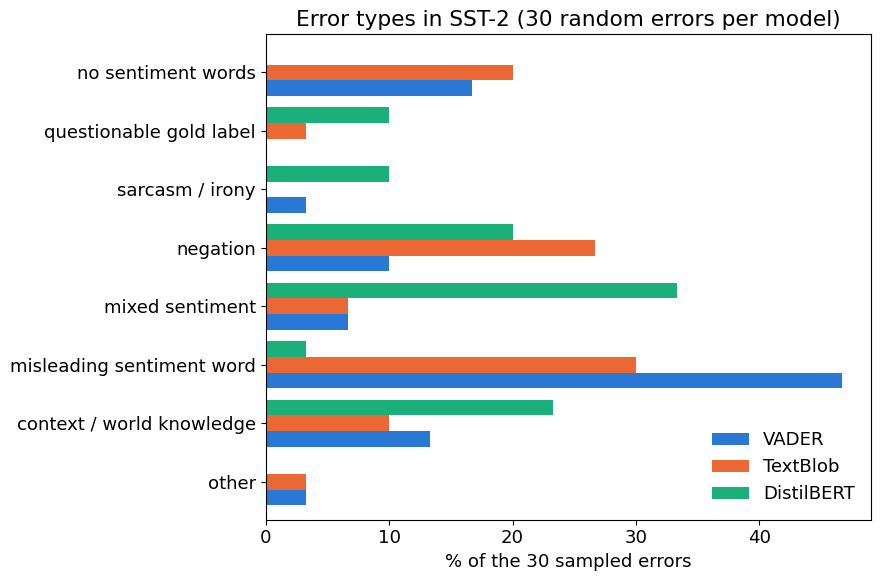

In [19]:
if os.path.exists("error_sample_labels.csv"):
    ax = percent.iloc[::-1].plot(kind="barh", figsize=(9, 6), color=colors, width=0.8)
    ax.set_xlabel("% of the 30 sampled errors")
    ax.set_ylabel("")
    ax.set_title("Error types in SST-2 (30 random errors per model)")
    ax.legend(loc="lower right", frameon=False)
    plt.tight_layout()
    plt.savefig("results/error_types.png", dpi=300)
    plt.savefig("results/error_types.pdf")
    plt.show()

### 6.3 Examples picked by hand (SST-2)

Picked after reading through the misclassified sentences. The model column says which model the example is meant for, but the predictions of all three are shown.

In [20]:
# (idx, model, error type)
picked = [
    (298, "VADER", "negation"),
    (154, "VADER", "misleading sentiment word"),
    (211, "VADER", "context / world knowledge"),
    (818, "VADER", "sarcasm / irony"),
    (310, "VADER", "mixed sentiment"),
    (486, "TextBlob", "negation"),
    (193, "TextBlob", "misleading sentiment word"),
    (89, "TextBlob", "mixed sentiment"),
    (709, "TextBlob", "sarcasm / irony"),
    (539, "TextBlob", "no sentiment words"),
    (685, "DistilBERT", "negation"),
    (22, "DistilBERT", "context / world knowledge"),
    (183, "DistilBERT", "sarcasm / irony"),
    (667, "DistilBERT", "mixed sentiment"),
    (519, "DistilBERT", "questionable gold label"),
]

def lab(x):
    return "pos" if x == 1 else "neg"

rows = []
for i, model, err in picked:
    r = df[df["idx"] == i].iloc[0]
    # make sure the model really got this one wrong
    assert r[model.lower() + "_pred"] != r["label"], i
    rows.append([i, model, err, r["sentence"], lab(r["label"]),
                 lab(r["vader_pred"]), lab(r["textblob_pred"]), lab(r["distilbert_pred"])])

examples = pd.DataFrame(rows, columns=["idx", "model", "error type", "sentence", "gold",
                                       "VADER", "TextBlob", "DistilBERT"])
examples.to_csv("results/error_examples.csv", index=False)
examples

,idx,model,error type,sentence,gold,VADER,TextBlob,DistilBERT
0,298,VADER,negation,serving sara does n't serve up a whole lot of laughs .,neg,pos,pos,neg
1,154,VADER,misleading sentiment word,a solid examination of the male midlife crisis .,pos,neg,pos,pos
2,211,VADER,context / world knowledge,to say this was done better in wilder 's some like it hot is like saying the sun rises in the east .,neg,pos,pos,neg
3,818,VADER,sarcasm / irony,the only excitement comes when the credits finally roll and you get to leave the theater .,neg,pos,pos,neg
4,310,VADER,mixed sentiment,"if you can stomach the rough content , it 's worth checking out for the performances alone .",pos,neg,pos,pos
5,486,TextBlob,negation,the script is n't very good ; not even someone as gifted as hoffman ( the actor ) can make it work .,neg,neg,pos,neg
6,193,TextBlob,misleading sentiment word,"morton uses her face and her body language to bring us morvern 's soul , even though the character is almost completely deadpan .",pos,pos,neg,pos
7,89,TextBlob,mixed sentiment,"we know the plot 's a little crazy , but it held my interest from start to finish .",pos,pos,neg,pos
8,709,TextBlob,sarcasm / irony,i thought my own watch had stopped keeping time as i slogged my way through clockstoppers .,neg,neg,pos,neg
9,539,TextBlob,no sentiment words,do not see this film .,neg,pos,pos,neg


In [21]:
# all DistilBERT mistakes on SST-2
df[~df["distilbert_correct"]][["idx", "sentence", "label", "distilbert_conf", "vader_pred", "textblob_pred"]]

,idx,sentence,label,distilbert_conf,vader_pred,textblob_pred
22,22,holden caulfield did it better .,0,0.990752,1,1
64,64,"the script kicks in , and mr. hartley 's distended pace and foot-dragging rhythms follow .",0,0.857642,1,1
87,87,jaglom ... put ( s ) the audience in the privileged position of eavesdropping on his characters,1,0.996092,1,1
92,92,"you wo n't like roger , but you will quickly recognize him .",0,0.998519,0,1
93,93,if steven soderbergh 's ` solaris ' is a failure it is a glorious failure .,1,0.999392,0,0
95,95,this riveting world war ii moral suspense story deals with the shadow side of american culture : racial prejudice in its ugly and diverse forms .,0,0.999312,0,0
107,107,what the director ca n't do is make either of val kilmer 's two personas interesting or worth caring about .,0,0.941034,1,1
115,115,sam mendes has become valedictorian at the school for soft landings and easy ways out .,0,0.996837,1,1
118,118,every nanosecond of the the new guy reminds you that you could be doing something else far more pleasurable .,0,0.987379,1,1
121,121,it seems to me the film is about the art of ripping people off without ever letting them consciously know you have done so,0,0.997744,1,1


## 7. Some hand-written test sentences

Not from either dataset, so there is no gold label. Just to see how each model reacts to a few specific cases, including the SST-2 style tokenization of "n't".

In [22]:
tests = [
    "The plot was predictable, but the acting was outstanding.",
    "The acting was outstanding, but the plot was predictable.",
    "the movie is not good .",
    "the movie is n't good .",
    "the movie isn't good.",
    "not bad at all .",
]

rows = []
for s in tests:
    out = clf(s)[0]
    rows.append([s, vader.polarity_scores(s)["compound"], TextBlob(s).sentiment.polarity,
                 out["label"], round(out["score"], 3)])

pd.DataFrame(rows, columns=["sentence", "VADER", "TextBlob", "DistilBERT", "DistilBERT conf"])

,sentence,VADER,TextBlob,DistilBERT,DistilBERT conf
0,"The plot was predictable, but the acting was outstanding.",0.7579,0.10,POSITIVE,1.000
1,"The acting was outstanding, but the plot was predictable.",0.3612,0.10,NEGATIVE,0.999
2,the movie is not good .,-0.3412,-0.35,NEGATIVE,1.000
3,the movie is n't good .,-0.3412,0.70,NEGATIVE,1.000
4,the movie isn't good.,-0.3412,0.70,NEGATIVE,1.000
5,not bad at all .,0.4310,0.35,POSITIVE,0.999
